## CSDID - Quarterly sample construction


1. **Activity threshold:** Primer acuerdo debe tener >= 12 muertes en 6 meses previos
2. **Control selection:** Eliminar observaciones inactivas del control risk set
3. **UCDP trimming:** Usar columna `real_observation` para respetar ventana oficial
4. **Covariables:** Construir pre_violence_level y age_at_treatment con pseudo-tratamiento

In [727]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from prettytable import PrettyTable
import numpy as np
from diff_diff import CallawaySantAnna, plot_event_study
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
from run_event_study import run_event_study
from pathlib import Path
import importlib.util

# Configuración
ACTIVITY_THRESHOLD = 12  # Muertes en 6 meses previos
SEED = 20240315

np.random.seed(SEED)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [728]:
columns = [
    'conflict_id', 'year_mo', 'year_mo_numeric', 
    'start_date', 'start_date_numeric', 'end_date', 'end_date_numeric',
    'best', 'country', 'agreement', 'isocode', 'isocode_num'
]

df = pd.read_csv(
    '../../../data/output/conflict_level/conflict_panel.csv',
    low_memory=False,
    usecols=columns
)

In [729]:
#==============================================================
# Convertir year-quarter a número (como Stata)
#==============================================================

def yq_to_numeric(year, quarter):
    """
    Convierte year y quarter a formato numérico de Stata.
    Stata cuenta quarters desde 1960q1 = 0
    Formula: (year - 1960) * 4 + (quarter - 1)
    """
    return (year - 1960) * 4 + (quarter - 1)

def numeric_to_yq_str(yq_numeric):
    """Convierte número quarterly de vuelta a string para debugging"""
    if pd.isna(yq_numeric):
        return np.nan
    year = 1960 + int(yq_numeric) // 4
    quarter = int(yq_numeric) % 4 + 1
    return f"{year}q{quarter}"

#==============================================================
# 1. MONTHLY -> QUARTERLY TIME + FIRST AGREEMENT
#==============================================================

# Extraer año y mes de year_mo (asumiendo formato "YYYY-MM")
df['year'] = df['year_mo'].str[:4].astype(int)
df['month'] = df['year_mo'].str[5:7].astype(int)
df['quarter'] = np.ceil(df['month'] / 3).astype(int)

# Crear yq numérico (como Stata)
df['yq'] = yq_to_numeric(df['year'], df['quarter'])

# Ordenar para cálculos acumulativos
df = df.sort_values(['conflict_id', 'yq']).reset_index(drop=True)

# Cumulative agreements por conflicto
df['cum_agree_monthly'] = df.groupby('conflict_id')['agreement'].cumsum()

# Primera vez que hay acuerdo (a nivel mensual)
df['first_agree_month'] = (
    (df['agreement'] == 1) & 
    (df['cum_agree_monthly'] == 1)
).astype(int)

# Encontrar el yq numérico del primer acuerdo
df['first_agree_yq'] = np.where(
    df['first_agree_month'] == 1,
    df['yq'],
    np.nan
)

# Propagar el primer quarter de acuerdo a todo el conflicto
first_agreement_quarter = (
    df[df['first_agree_month'] == 1]
    .groupby('conflict_id')['yq']
    .min()  # Usar min en vez de first para asegurar el primero
)

df = df.merge(
    first_agreement_quarter.rename('first_agreement_quarter'),
    on='conflict_id',
    how='left'
)


In [730]:
#==============================================================
# 2. COLLAPSE TO QUARTERLY
#==============================================================

agg_dict = {
    'year_mo': 'first',
    'best': 'sum',
    'agreement': 'max',
    'first_agree_month': 'max',
    'country': 'first',
    'start_date': 'first',
    'end_date': 'first',
    'first_agreement_quarter': 'first',
    'isocode_num': 'first'
}

df_quarterly = (
    df.groupby(['conflict_id', 'yq'])
    .agg(agg_dict)
    .reset_index()
)

# Renombrar first_agree_month a first_agreement
df_quarterly = df_quarterly.rename(columns={'first_agree_month': 'first_agreement'})

# Crear ln_deaths
df_quarterly['ln_deaths'] = np.log(df_quarterly['best'] + 1)

# Ordenar para panel
df_quarterly = df_quarterly.sort_values(['conflict_id', 'yq']).reset_index(drop=True)


In [731]:
#==============================================================
# 3. CONVERT UCDP START / END DATES TO QUARTERS
#==============================================================

# Convertir start_date a quarter numérico
df_quarterly['start_year'] = df_quarterly['start_date'].str[:4].astype(int)
df_quarterly['start_month'] = df_quarterly['start_date'].str[5:7].astype(int)
df_quarterly['start_quarter'] = np.ceil(df_quarterly['start_month'] / 3).astype(int)
df_quarterly['start_yq'] = yq_to_numeric(
    df_quarterly['start_year'], 
    df_quarterly['start_quarter']
)

# Convertir end_date a quarter numérico
df_quarterly['end_year'] = df_quarterly['end_date'].str[:4].astype(int)
df_quarterly['end_month'] = df_quarterly['end_date'].str[5:7].astype(int)
df_quarterly['end_quarter'] = np.ceil(df_quarterly['end_month'] / 3).astype(int)
df_quarterly['end_yq'] = yq_to_numeric(
    df_quarterly['end_year'], 
    df_quarterly['end_quarter']
)

#==============================================================
# 4. EVENT TIME AT QUARTERLY LEVEL
#==============================================================

df_quarterly['event_time'] = np.where(
    pd.notna(df_quarterly['first_agreement_quarter']),
    df_quarterly['yq'] - df_quarterly['first_agreement_quarter'],
    np.nan
)


In [732]:
#==============================================================
# 5. ACTIVITY THRESHOLD FOR TREATED UNITS
#==============================================================
print('Treated conflicts before activity threshold:', df_quarterly['first_agreement'].sum())
print(df_quarterly.loc[df_quarterly['first_agreement']==1]['conflict_id'].unique())
# Calcular deaths en los 2 quarters previos
df_quarterly['deaths_lag1'] = df_quarterly.groupby('conflict_id')['best'].shift(1)
df_quarterly['deaths_lag2'] = df_quarterly.groupby('conflict_id')['best'].shift(2)
df_quarterly['deaths_prev2q'] = (
    df_quarterly['deaths_lag1'] + 
    df_quarterly['deaths_lag2']
)

# Deaths previos en el momento del tratamiento
df_quarterly['_prev2_at_treat'] = np.where(
    df_quarterly['first_agreement'] == 1,
    df_quarterly['deaths_prev2q'] + df_quarterly['best'],  # Incluir el quarter del tratamiento
    np.nan
)

conflict_prev2 = (
    df_quarterly.groupby('conflict_id')['_prev2_at_treat']
    .max()
    .rename('_conflict_prev2')
)

df_quarterly = df_quarterly.merge(conflict_prev2, on='conflict_id', how='left')

# Identificar tratamientos con baja actividad
df_quarterly['_low_treat'] = (
    pd.notna(df_quarterly['first_agreement_quarter']) &
    ((df_quarterly['_conflict_prev2'] < ACTIVITY_THRESHOLD) | 
     pd.isna(df_quarterly['_conflict_prev2']))
)

# Guardar original para summary stats
df_quarterly['first_agreement_original'] = df_quarterly['first_agreement'].copy()
df_quarterly['first_agreement_quarter_original'] = df_quarterly['first_agreement_quarter'].copy()


# Eliminar estos tratamientos
df_quarterly.loc[df_quarterly['_low_treat'], 'first_agreement_quarter'] = np.nan
df_quarterly.loc[df_quarterly['_low_treat'], 'first_agreement'] = 0
df_quarterly.loc[df_quarterly['_low_treat'], 'event_time'] = np.nan

print(f"\nFILTRO 1: Activity Threshold")
print(f"  Treatments eliminated by low activity: {df_quarterly['_low_treat'].sum()}")
print('Treated conflicts after activity threshold:', df_quarterly['first_agreement'].sum())
print(df_quarterly.loc[df_quarterly['first_agreement']==1]['conflict_id'].unique())



Treated conflicts before activity threshold: 71
[  209   218   221   222   230   233   234   251   267   269   283   287
   288   289   299   300   308   309   314   315   316   327   329   330
   332   333   336   337   341   342   352   366   369   372   374   382
   384   385   386   387   388   389   390   392   393   394   395   397
   398   401   402   403   404   408   409   410   412   416   417   419
   421   423   426 11344 11345 11346 11347 13243 13306 13324 14275]

FILTRO 1: Activity Threshold
  Treatments eliminated by low activity: 720
Treated conflicts after activity threshold: 66
[  209   218   221   222   230   233   234   251   267   269   283   288
   289   299   300   308   309   314   316   327   329   330   332   333
   336   337   341   352   366   369   374   382   384   385   386   388
   389   390   392   393   394   395   397   398   401   402   403   404
   408   409   410   412   416   417   419   421   423   426 11344 11345
 11346 11347 13243 13306 13324 1

In [733]:
treated = df_quarterly.loc[df_quarterly["first_agreement_original"] == 1, ["conflict_id", "year_mo", "_prev2_at_treat", 'country']].copy()
treated["status"] = np.where(treated["_prev2_at_treat"] >= 12, "Active", "Inactive")


def summary_stats(x):
    return pd.Series({
        "N": x.shape[0],
        "Mean": x.mean(),
        "Median": x.median(),
        "SD": x.std()
    })

summary_all = summary_stats(treated["_prev2_at_treat"])
summary_active = summary_stats(treated.loc[treated["status"] == "Active", "_prev2_at_treat"])
summary_inactive = summary_stats(treated.loc[treated["status"] == "Inactive", "_prev2_at_treat"])
bins = [1, 12, 25, 100, 500, 1000, np.inf]
labels = ["1–11 deaths", "12–24 deaths", "25–99 deaths",
          "100–499 deaths", "500–999 deaths", "1,000+ deaths"]

treated["death_bin"] = pd.cut(
    treated["_prev2_at_treat"],
    bins=bins,
    labels=labels,
    right=False
)
dist_all = treated["death_bin"].value_counts().reindex(labels, fill_value=0)
dist_active = treated.loc[treated["status"] == "Active", "death_bin"].value_counts().reindex(labels, fill_value=0)
dist_inactive = treated.loc[treated["status"] == "Inactive", "death_bin"].value_counts().reindex(labels, fill_value=0)
table = pd.DataFrame({
    "All": [
        summary_all["Mean"],
        summary_all["Median"],
        summary_all["SD"],
        *dist_all.tolist()
    ],
    "Active": [
        summary_active["Mean"],
        summary_active["Median"],
        summary_active["SD"],
        *dist_active.tolist()
    ],
    "Inactive": [
        summary_inactive["Mean"],
        summary_inactive["Median"],
        summary_inactive["SD"],
        *dist_inactive.tolist()
    ]
}, index=[
    "Mean", "Median", "SD",
    "1–11 deaths", "12–24 deaths", "25–99 deaths",
    "100–499 deaths", "500–999 deaths", "1,000+ deaths"
])

print(table)

                         All        Active  Inactive
Mean             4139.390114   4452.525729  6.000000
Median            303.000000    329.125000  7.000000
SD              20763.258304  21514.219455  2.828427
1–11 deaths         5.000000      0.000000  5.000000
12–24 deaths        4.000000      4.000000  0.000000
25–99 deaths       14.000000     14.000000  0.000000
100–499 deaths     23.000000     23.000000  0.000000
500–999 deaths      7.000000      7.000000  0.000000
1,000+ deaths      18.000000     18.000000  0.000000


In [743]:
df_quarterly.loc[df_quarterly['first_agreement_original'] == 1, ['conflict_id', 'yq', 'first_agreement','first_agreement_quarter', '_prev2_at_treat']]

,conflict_id,yq,first_agreement,first_agreement_quarter,_prev2_at_treat
158,209,130,1,130.0,347.000000
297,218,125,1,125.0,19.250000
667,221,207,1,207.0,239.250000
818,222,214,1,214.0,21.000000
1380,230,200,1,200.0,110.000000
...,...,...,...,...,...
20844,11347,224,1,224.0,57.000000
22310,13243,250,1,250.0,68770.264791
22710,13306,218,1,218.0,394.500000
22881,13324,245,1,245.0,55.000000


In [650]:
#==============================================================
# 6. CONTROL-SELECTION RULE
#==============================================================

df_quarterly['_inactive'] = (
    (df_quarterly['deaths_prev2q'] < ACTIVITY_THRESHOLD) | 
    pd.isna(df_quarterly['deaths_prev2q'])
)

df_quarterly['_is_ctrl_period'] = (
    pd.isna(df_quarterly['first_agreement_quarter']) |
    (pd.notna(df_quarterly['first_agreement_quarter']) & 
     (df_quarterly['yq'] < df_quarterly['first_agreement_quarter']))
)

df_quarterly['_drop_inactive'] = (
    df_quarterly['_inactive'] & 
    df_quarterly['_is_ctrl_period']
)

# EXCEPCIÓN: no eliminar el quarter del tratamiento
df_quarterly.loc[df_quarterly['first_agreement'] == 1, '_drop_inactive'] = False

n_drop_inactive = df_quarterly['_drop_inactive'].sum()
print(f"\nFILTRO 2: Control Selection Rule")
print(f"  Obs before: {len(df_quarterly):,}")
print(f"  Obs to drop (inactive controls): {n_drop_inactive:,}")

df_quarterly = df_quarterly[~df_quarterly['_drop_inactive']].copy()

print(f"  Obs after: {len(df_quarterly):,}")



FILTRO 2: Control Selection Rule
  Obs before: 28,944
  Obs to drop (inactive controls): 18,944
  Obs after: 10,000


In [651]:
#==============================================================
# 7. TRIM USING ORIGINAL UCDP CONFLICT WINDOW
#==============================================================

# Filtro 1: yq < start_yq (excepto first_agreement)
mask_before_start = (
    (df_quarterly['yq'] < df_quarterly['start_yq']) & 
    (df_quarterly['first_agreement'] != 1)
)

n_before_start = mask_before_start.sum()
df_quarterly = df_quarterly[~mask_before_start].copy()

# Identificar observaciones de control
df_quarterly['_is_control_obs'] = (
    pd.isna(df_quarterly['first_agreement_quarter']) |
    (pd.notna(df_quarterly['first_agreement_quarter']) & 
     (df_quarterly['yq'] < df_quarterly['first_agreement_quarter']))
)

# Filtro 2: yq > end_yq para controles (excepto first_agreement)
mask_after_end = (
    (df_quarterly['yq'] > df_quarterly['end_yq']) & 
    df_quarterly['_is_control_obs'] & 
    (df_quarterly['first_agreement'] != 1)
)

n_after_end = mask_after_end.sum()
df_quarterly = df_quarterly[~mask_after_end].copy()

print(f"\nFILTRO 3: UCDP Trimming")
print(f"  Obs dropped before start_yq: {n_before_start:,}")
print(f"  Obs dropped after end_yq: {n_after_end:,}")
print(f"  Obs remaining: {len(df_quarterly):,}")
print(f"  Conflicts remaining: {df_quarterly['conflict_id'].nunique()}")


FILTRO 3: UCDP Trimming
  Obs dropped before start_yq: 0
  Obs dropped after end_yq: 86
  Obs remaining: 9,914
  Conflicts remaining: 184


In [652]:
#==============================================================
# 8. GVAR AT QUARTERLY LEVEL
#==============================================================

df_quarterly['gvar'] = df_quarterly['first_agreement_quarter'].fillna(0)

# Resumen final
print(f"\nRESUMEN FINAL:")
print(f"  Total observations: {len(df_quarterly):,}")
print(f"  Total conflicts: {df_quarterly['conflict_id'].nunique()}")
print(f"  Treated conflicts: {(df_quarterly.groupby('conflict_id')['gvar'].max() != 0).sum()}")
print(f"  Control conflicts: {(df_quarterly.groupby('conflict_id')['gvar'].max() == 0).sum()}")


RESUMEN FINAL:
  Total observations: 9,914
  Total conflicts: 184
  Treated conflicts: 66
  Control conflicts: 118


In [653]:
#==============================================================
# 9. ASSIGN PSEUDO-TREATMENT TIMING TO NEVER-TREATED
#==============================================================

# Extraer quarters de tratamiento de los conflictos tratados
treated_conflicts = df_quarterly[df_quarterly['gvar'] != 0].copy()
treated_quarters = (
    treated_conflicts.groupby('conflict_id')
    .first()
    .reset_index()[['conflict_id', 'first_agreement_quarter']]
)
treated_quarters['draw_id'] = range(1, len(treated_quarters) + 1)

# Número total de opciones para sortear
n_draws = len(treated_quarters)

# Identificar conflictos never-treated
control_conflicts = (
    df_quarterly[df_quarterly['gvar'] == 0]
    .groupby('conflict_id')
    .first()
    .reset_index()[['conflict_id']]
)

# Asignar pseudo-tratamiento aleatoriamente (seed para reproducibilidad)
np.random.seed(20240315)
control_conflicts['u'] = np.random.uniform(0, 1, len(control_conflicts))
control_conflicts['draw_id'] = np.ceil(control_conflicts['u'] * n_draws).astype(int)
control_conflicts['draw_id'] = control_conflicts['draw_id'].replace(0, 1)  # Si sale 0, poner 1

# Merge para obtener el pseudo_treat_q
control_conflicts = control_conflicts.merge(
    treated_quarters[['draw_id', 'first_agreement_quarter']],
    on='draw_id',
    how='left'
)
control_conflicts = control_conflicts.rename(
    columns={'first_agreement_quarter': 'pseudo_treat_q'}
)
control_conflicts = control_conflicts[['conflict_id', 'pseudo_treat_q']]

# Merge de vuelta al dataframe principal
df_quarterly = df_quarterly.merge(
    control_conflicts,
    on='conflict_id',
    how='left'
)

# Crear pseudo_event_time para controles
df_quarterly['pseudo_event_time'] = np.where(
    (df_quarterly['gvar'] == 0) & pd.notna(df_quarterly['pseudo_treat_q']),
    df_quarterly['yq'] - df_quarterly['pseudo_treat_q'],
    np.nan
)

print(f"\nPseudo-tratamiento asignado:")
print(f"  Conflictos con pseudo-tratamiento: {df_quarterly['pseudo_treat_q'].notna().sum()}")

#==============================================================
# 10. CONSTRUCT pre_violence_level
#==============================================================

# Para tratados: ln_deaths en t-4 a t-2 respecto al tratamiento real
df_quarterly['help_level_t'] = np.where(
    (df_quarterly['event_time'] >= -4) & 
    (df_quarterly['event_time'] <= -2) & 
    (df_quarterly['gvar'] != 0),
    df_quarterly['ln_deaths'],
    np.nan
)

# Para controles: ln_deaths en t-4 a t-2 respecto al pseudo-tratamiento
df_quarterly['help_level_c'] = np.where(
    (df_quarterly['pseudo_event_time'] >= -4) & 
    (df_quarterly['pseudo_event_time'] <= -2) & 
    (df_quarterly['gvar'] == 0),
    df_quarterly['ln_deaths'],
    np.nan
)

# Combinar
df_quarterly['help_level'] = df_quarterly['help_level_t']
df_quarterly.loc[df_quarterly['gvar'] == 0, 'help_level'] = \
    df_quarterly.loc[df_quarterly['gvar'] == 0, 'help_level_c']

# Calcular promedio por conflicto
df_quarterly['pre_violence_level'] = (
    df_quarterly.groupby('conflict_id')['help_level']
    .transform('mean')
)

# Fallback: si falta, usar promedio general del conflicto
tmp_mean_ln = df_quarterly.groupby('conflict_id')['ln_deaths'].transform('mean')
df_quarterly['pre_violence_level'] = df_quarterly['pre_violence_level'].fillna(tmp_mean_ln)

# Limpiar variables auxiliares
df_quarterly = df_quarterly.drop(
    columns=['help_level', 'help_level_t', 'help_level_c']
)

print(f"\nPre-violence level creado:")
print(f"  Media: {df_quarterly['pre_violence_level'].mean():.4f}")
print(f"  Missing: {df_quarterly['pre_violence_level'].isna().sum()}")

#==============================================================
# 11. CONSTRUCT age_at_treatment
#==============================================================

# Para tratados: first_agreement_quarter - start_yq
df_quarterly['age_at_treatment'] = np.where(
    df_quarterly['gvar'] != 0,
    df_quarterly['first_agreement_quarter'] - df_quarterly['start_yq'],
    np.nan
)

# Para controles: pseudo_treat_q - start_yq
df_quarterly.loc[
    (df_quarterly['gvar'] == 0) & pd.notna(df_quarterly['pseudo_treat_q']),
    'age_at_treatment'
] = (
    df_quarterly.loc[
        (df_quarterly['gvar'] == 0) & pd.notna(df_quarterly['pseudo_treat_q']),
        'pseudo_treat_q'
    ] - 
    df_quarterly.loc[
        (df_quarterly['gvar'] == 0) & pd.notna(df_quarterly['pseudo_treat_q']),
        'start_yq'
    ]
)

# Propagar a todo el conflicto (tomar la media por conflicto)
age_tmp = df_quarterly.groupby('conflict_id')['age_at_treatment'].transform('mean')
df_quarterly['age_at_treatment'] = age_tmp
df_quarterly['age_at_treatment'] = df_quarterly['age_at_treatment'].fillna(0)




Pseudo-tratamiento asignado:
  Conflictos con pseudo-tratamiento: 2631

Pre-violence level creado:
  Media: 2.9664
  Missing: 0


In [654]:
#==============================================================
# 9. PREPARAR PARA EXPORTAR A STATA
#==============================================================

# Crear versión string de yq para referencia
df_quarterly['yq_str'] = df_quarterly['yq'].apply(numeric_to_yq_str)

# Seleccionar columnas clave para exportar
export_cols = [
    'conflict_id', 'yq', 'ln_deaths', 'best', 
    'agreement', 'first_agreement', 'country',
    'first_agreement_quarter', 'event_time', 'gvar',
    'deaths_prev2q',
    'yq_str',  # Solo para referencia visual,
    'age_at_treatment',
    'pre_violence_level',
    'isocode_num'
]

df_export = df_quarterly[export_cols].copy()

# IMPORTANTE: Asegurar que las variables numéricas se exporten como números
# Convertir a int donde sea apropiado (evitar .0 en el CSV)
int_cols = ['conflict_id', 'yq', 'best', 'agreement', 'first_agreement', 
             'gvar']

for col in int_cols:
    if col in df_export.columns:
        df_export[col] = df_export[col].fillna(0).astype(int)

# Para las columnas que pueden tener NaN, mantenerlas como float
float_cols = ['first_agreement_quarter', 'event_time', 'deaths_prev2q', 'age_at_treatment','pre_violence_level']
for col in float_cols:
    if col in df_export.columns:
        df_export[col] = df_export[col].astype(float)

# Guardar
df_export.to_csv(
    '../../../data/output/conflict_level/quarter_sample_for_csdid.csv', 
    index=False,
    na_rep='.'  # Usar '.' para missing values como en Stata
)

## **CSDID Quarterly**

In [655]:
def stata_table(results, w_start=-6, w_end=6):
    t = PrettyTable(["", "Coefficient", "Std. err.", "z", "P>|z|", 
                     "[95% conf. interval]"])
    t.align = "r"
    
    # Filtrar (excluyendo -1)
    e = {k: v for k, v in results.event_study_effects.items() 
         if w_start <= k <= w_end and k != -1}  # ← EXCLUIR -1
    
    # Pre/Post avg (sin incluir -1)
    pre = [v for k, v in e.items() if k < 0]  # k < 0 ya excluye -1 porque e no lo tiene
    post = [v for k, v in e.items() if k >= 0]
    
    for name, data in [("Pre_avg", pre), ("Post_avg", post)]:
        if len(data) > 0:  # Solo si hay datos
            avg = np.mean([x['effect'] for x in data])
            se = np.sqrt(np.mean([x['se']**2 for x in data]))
            z = avg / se
            p = 2 * (1 - stats.norm.cdf(abs(z)))
            ci_l, ci_u = avg - 1.96*se, avg + 1.96*se
            t.add_row([name, f"{avg:.7g}", f"{se:.7g}", f"{z:.2f}", 
                       f"{p:.3f}", f"{ci_l:.7g}    {ci_u:.7g}"])
    
    # Efectos individuales (sin -1)
    for k in sorted(e.keys()):
        v = e[k]
        name = f"tm{abs(k)}" if k < 0 else f"tp{k}"
        t.add_row([name, f"{v['effect']:.7g}", f"{v['se']:.7g}", 
                   f"{v['t_stat']:.2f}", f"{v['p_value']:.3f}",
                   f"{v['conf_int'][0]:.7g}    {v['conf_int'][1]:.7g}"])
    
    print(t)

In [656]:
# Configuración para replicar Stata csdid2
cs = CallawaySantAnna(
    control_group='not_yet_treated',  # notyet en Stata
    estimation_method='dr',           # drimp en Stata
    anticipation=0,                   # Sin anticipation
    base_period='universal',            # Default de Stata
    cluster='isocode_num',                   # Clustering por conflict_id
    n_bootstrap=999,                  # Bootstrap como Stata
    bootstrap_weights='rademacher',   # Tipo estándar
    seed=12345,                       # Reproducibilidad
    alpha=0.05
)

results = cs.fit(
    df_quarterly,
    outcome='ln_deaths',
    unit='conflict_id',
    time='yq',
    first_treat='gvar',
    aggregate='event_study'
)

# Imprimir resultados
stata_table(results, w_start=-8, w_end=8)

/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/.venv/lib/python3.11/site-packages/diff_diff/staggered_bootstrap.py:320: RuntimeWarning: Bootstrap SE is non-finite or zero (n_valid=999) in ATT(g=125.0, t=219). Returning NaN for SE/CI/p-value.
  se, ci, p_value = self._compute_effect_bootstrap_stats(
/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/.venv/lib/python3.11/site-packages/diff_diff/staggered_bootstrap.py:320: RuntimeWarning: Bootstrap SE is non-finite or zero (n_valid=999) in ATT(g=125.0, t=220). Returning NaN for SE/CI/p-value.
  se, ci, p_value = self._compute_effect_bootstrap_stats(
/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/.venv/lib/python3.11/site-packages/diff_diff/staggered_bootstrap.py:320: RuntimeWarning: Bootstrap SE is no

+----------+-------------+-----------+-------+-------+--------------------------+
|          | Coefficient | Std. err. |     z | P>|z| |     [95% conf. interval] |
+----------+-------------+-----------+-------+-------+--------------------------+
|  Pre_avg |   -0.244422 |  0.217351 | -1.12 | 0.261 |   -0.6704299    0.181586 |
| Post_avg |  -0.9103912 | 0.2169325 | -4.20 | 0.000 |  -1.335579    -0.4852034 |
|    tm8.0 | -0.04517252 | 0.1298303 | -0.35 | 0.793 |  -0.2922404    0.2096449 |
|    tm7.0 |   -1.114946 | 0.2568891 | -4.34 | 0.001 |  -1.598633    -0.6306977 |
|    tm6.0 |   -1.021757 | 0.2507218 | -4.08 | 0.001 |  -1.481155    -0.5400912 |
|    tm5.0 |   0.1587885 | 0.1215395 |  1.31 | 0.162 | -0.06844435    0.4012663 |
|    tm4.0 |   0.8165096 | 0.2332662 |  3.50 | 0.001 |    0.4090208    1.263075 |
|    tm3.0 |  -0.2928806 |  0.292594 | -1.00 | 0.374 |  -0.8398802    0.2805479 |
|    tm2.0 |  -0.2114955 | 0.1737372 | -1.22 | 0.258 |  -0.5572019    0.1110524 |
|    tp0.0 |   0

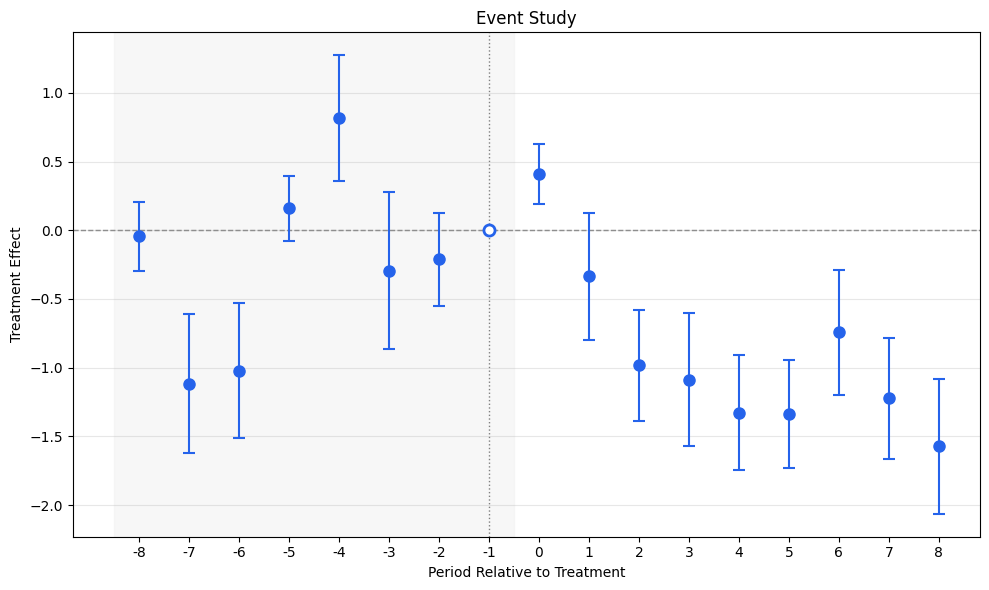

<Axes: title={'center': 'Event Study'}, xlabel='Period Relative to Treatment', ylabel='Treatment Effect'>

In [657]:
plot_event_study(results, periods = [-8,-7,-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6,7,8])

In [658]:
# Configuración para replicar Stata csdid2
cs = CallawaySantAnna(
    control_group='not_yet_treated',  # notyet en Stata
    estimation_method='ipw',           # ipw en Stata
    anticipation=0,                   # Sin anticipation
    base_period='universal',            # Default de Stata
    cluster='isocode_num',                   # Clustering por conflict_id
    n_bootstrap=999,                  # Bootstrap como Stata
    bootstrap_weights='rademacher',   # Tipo estándar
    seed=12345,                       # Reproducibilidad
    alpha=0.05
)


results = cs.fit(
    df_quarterly,
    outcome='ln_deaths',
    unit='conflict_id',
    time='yq',
    first_treat='gvar',
    aggregate='event_study',
    covariates = ['pre_violence_level', 'age_at_treatment']
)

# Imprimir resultados
stata_table(results,  w_start=-8, w_end=8)

/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/.venv/lib/python3.11/site-packages/diff_diff/staggered_bootstrap.py:320: RuntimeWarning: Bootstrap SE is non-finite or zero (n_valid=999) in ATT(g=125.0, t=219). Returning NaN for SE/CI/p-value.
  se, ci, p_value = self._compute_effect_bootstrap_stats(
/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/.venv/lib/python3.11/site-packages/diff_diff/staggered_bootstrap.py:320: RuntimeWarning: Bootstrap SE is non-finite or zero (n_valid=999) in ATT(g=125.0, t=220). Returning NaN for SE/CI/p-value.
  se, ci, p_value = self._compute_effect_bootstrap_stats(
/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/.venv/lib/python3.11/site-packages/diff_diff/staggered_bootstrap.py:320: RuntimeWarning: Bootstrap SE is no

+----------+-------------+-----------+-------+-------+-------------------------+
|          | Coefficient | Std. err. |     z | P>|z| |    [95% conf. interval] |
+----------+-------------+-----------+-------+-------+-------------------------+
|  Pre_avg |  -0.3642265 | 0.2427463 | -1.50 | 0.134 | -0.8400093    0.1115563 |
| Post_avg |  -0.9377844 | 0.2310005 | -4.06 | 0.000 | -1.390545    -0.4850234 |
|    tm8.0 |  0.03626614 | 0.2454393 |  0.15 | 0.843 | -0.4377926    0.5145669 |
|    tm7.0 |   -1.176399 | 0.2671101 | -4.40 | 0.001 | -1.671481    -0.6426095 |
|    tm6.0 |   -1.431572 | 0.2748809 | -5.21 | 0.001 |    -1.95316    -0.88538 |
|    tm5.0 |  -0.1385211 | 0.1477512 | -0.94 | 0.392 |  -0.417826    0.1456602 |
|    tm4.0 |   0.7214976 | 0.2557228 |  2.82 | 0.001 |   0.2739475    1.228115 |
|    tm3.0 |  -0.4270166 |  0.292113 | -1.46 | 0.160 | -0.9724951    0.1458097 |
|    tm2.0 |  -0.1338404 | 0.1810473 | -0.74 | 0.496 | -0.4708168    0.1995435 |
|    tp0.0 |   0.3516123 | 0

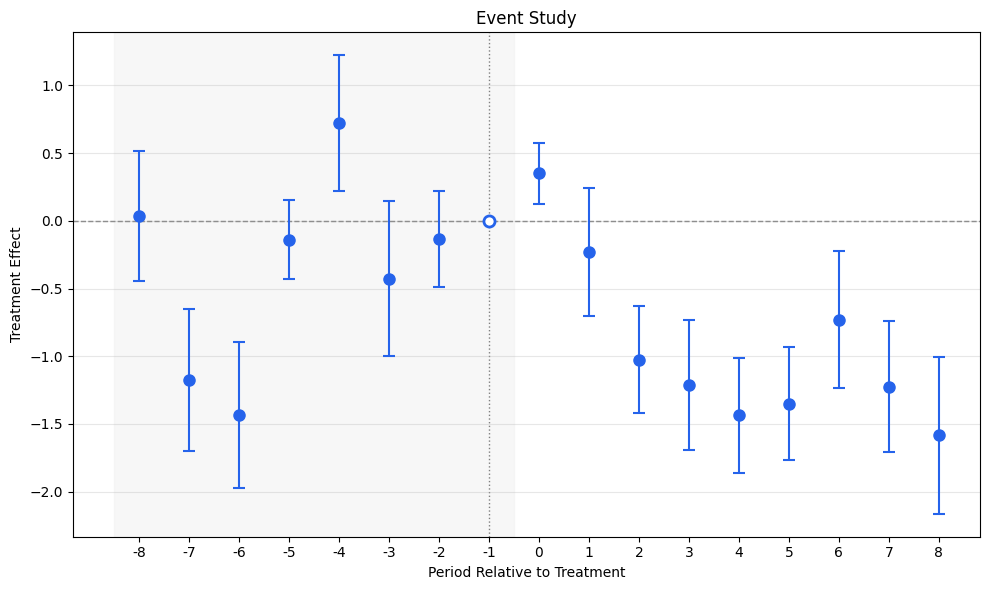

<Axes: title={'center': 'Event Study'}, xlabel='Period Relative to Treatment', ylabel='Treatment Effect'>

In [659]:
plot_event_study(results, periods = [-8,-7,-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6,7,8])

## **Semesterly sample construction**


In [660]:
# ==============================================================
# AGREGAR DE QUARTERLY A SEMESTRAL
# ==============================================================
df_semester = df_quarterly.copy()

# 1. Crear identificador de semestre a partir de year y quarter
df_semester['year_num'] = df_semester['yq'].apply(lambda x: 1960 + int(x) // 4)
df_semester['quarter_num'] = df_semester['yq'].apply(lambda x: int(x) % 4 + 1)

# Determinar semestre: Q1-Q2 = S1, Q3-Q4 = S2
df_semester['semester'] = np.where(df_semester['quarter_num'] <= 2, 1, 2)

# Crear identificador numérico de semestre (estilo yq de Stata)
# Semestres desde 1960S1 = 0
df_semester['ys'] = (df_semester['year_num'] - 1960) * 2 + (df_semester['semester'] - 1)

# 2. Agregar/colapsar a nivel semestral
agg_dict = {
    'best': 'sum',                          # Sumar muertes
    'agreement': 'max',                     # Max de acuerdos
    'first_agreement': 'max',               # Max de first_agreement
    'country': 'first',
    'start_yq': 'first',
    'end_yq': 'first',
    'first_agreement_quarter': 'first',     # Mantener el quarter original
    'pre_violence_level': 'first',
    'age_at_treatment':'first',
    'isocode_num': 'first'
}

df_semester_agg = (
    df_semester.groupby(['conflict_id', 'ys', 'year_num', 'semester'])
    .agg(agg_dict)
    .reset_index()
)

df_semester_agg['ln_deaths'] = np.log(df_semester_agg['best'] + 1)
# 3. Convertir first_agreement_quarter a semestre (gvar)
def quarter_to_semester(yq):
    """Convierte quarter numérico a semestre numérico"""
    if pd.isna(yq):
        return np.nan
    year = 1960 + int(yq) // 4
    quarter = int(yq) % 4 + 1
    semester = 1 if quarter <= 2 else 2
    ys = (year - 1960) * 2 + (semester - 1)
    return ys

df_semester_agg['first_agreement_semester'] = (
    df_semester_agg['first_agreement_quarter'].apply(quarter_to_semester)
)

# 4. Crear gvar para semestres
df_semester_agg['gvar'] = df_semester_agg['first_agreement_semester'].fillna(0)

## **CSDID**


In [661]:
# ==============================================================
# 6. CALLAWAY-SANT'ANNA A NIVEL SEMESTRAL
# ==============================================================

cs_semester = CallawaySantAnna(
    control_group='not_yet_treated',
    estimation_method='dr',
    anticipation=0,
    base_period='universal',
    cluster='isocode_num',
    n_bootstrap=999,
    bootstrap_weights='rademacher',
    seed=12345,
    alpha=0.05
)

results_semester = cs_semester.fit(
    df_semester_agg,
    outcome='ln_deaths',
    unit='conflict_id',
    time='ys',
    first_treat='gvar',
    aggregate='event_study'
)

# Tabla estilo Stata
stata_table(results_semester, w_start=-4, w_end=6)  # Ventana más corta para semestres

+----------+-------------+-----------+-------+-------+--------------------------+
|          | Coefficient | Std. err. |     z | P>|z| |     [95% conf. interval] |
+----------+-------------+-----------+-------+-------+--------------------------+
|  Pre_avg | -0.08293954 | 0.2030405 | -0.41 | 0.683 |  -0.4808989    0.3150199 |
| Post_avg |  -0.9865916 | 0.3347258 | -2.95 | 0.003 |  -1.642654    -0.3305291 |
|    tm4.0 |  0.09225919 | 0.2588893 |  0.36 | 0.707 |  -0.4000324    0.5728207 |
|    tm3.0 |  -0.6119423 | 0.1763188 | -3.47 | 0.001 | -0.9692719    -0.2754845 |
|    tm2.0 |   0.2708645 | 0.1598886 |  1.69 | 0.092 | -0.04113971    0.5830492 |
|    tp0.0 |   0.5580125 | 0.1974953 |  2.83 | 0.001 |     0.178679    0.947274 |
|    tp1.0 |   -1.051121 | 0.3323825 | -3.16 | 0.001 |  -1.688367    -0.4534274 |
|    tp2.0 |   -1.673334 |  0.346382 | -4.83 | 0.001 |    -2.32888    -1.005904 |
|    tp3.0 |  -0.9875924 | 0.3455175 | -2.86 | 0.008 |  -1.673321    -0.3056228 |
|    tp4.0 |   -

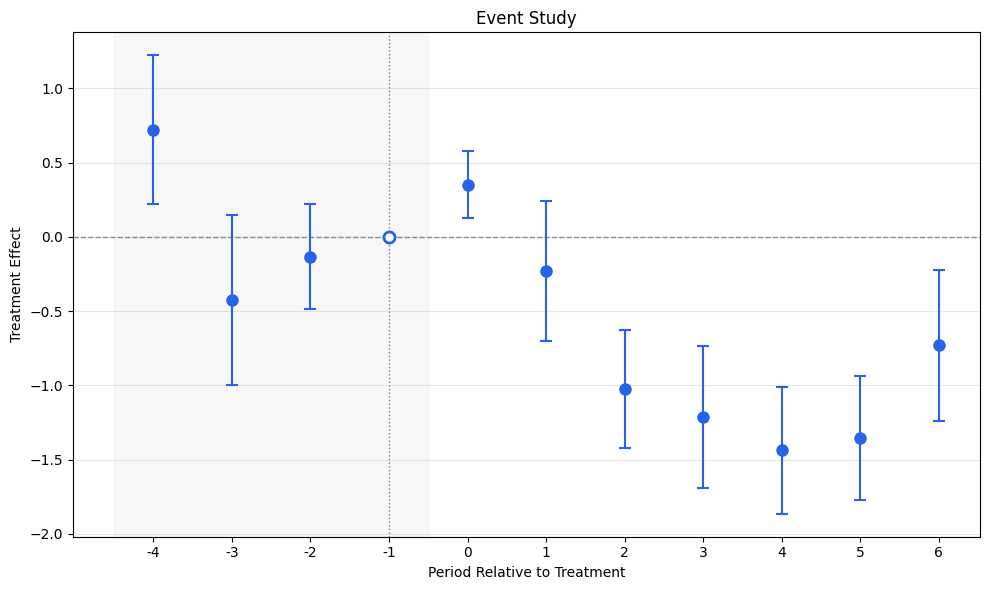

<Axes: title={'center': 'Event Study'}, xlabel='Period Relative to Treatment', ylabel='Treatment Effect'>

In [662]:
plot_event_study(results, periods = [-4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6])

In [663]:
cs_semester = CallawaySantAnna(
    control_group='not_yet_treated',
    estimation_method='ipw',
    anticipation=0,
    base_period='universal',
    cluster='isocode_num',
    n_bootstrap=999,
    bootstrap_weights='rademacher',
    seed=12345,
    alpha=0.05
)

results_semester = cs_semester.fit(
    df_semester_agg,
    outcome='ln_deaths',
    unit='conflict_id',
    time='ys',
    first_treat='gvar',
    aggregate='event_study',
    covariates=['pre_violence_level', 'age_at_treatment']
)

In [664]:
stata_table(results_semester, w_start=-4, w_end=6)  # Ventana más corta para semestres

+----------+--------------+-----------+-------+-------+--------------------------+
|          |  Coefficient | Std. err. |     z | P>|z| |     [95% conf. interval] |
+----------+--------------+-----------+-------+-------+--------------------------+
|  Pre_avg |   -0.2290026 | 0.2660909 | -0.86 | 0.389 |  -0.7505407    0.2925355 |
| Post_avg |   -0.9844594 | 0.3440233 | -2.86 | 0.004 |  -1.658745    -0.3101737 |
|    tm4.0 | -0.009404745 |  0.318943 | -0.03 | 0.981 |    -0.6236552    0.59357 |
|    tm3.0 |   -0.9031435 |  0.263591 | -3.43 | 0.001 |  -1.399751    -0.4107371 |
|    tm2.0 |    0.2255406 |  0.202998 |  1.11 | 0.272 |  -0.1872093    0.6035422 |
|    tp0.0 |     0.343994 | 0.1967641 |  1.75 | 0.080 | -0.01764338    0.7240168 |
|    tp1.0 |    -1.076297 | 0.3294902 | -3.27 | 0.001 |  -1.711767    -0.4513914 |
|    tp2.0 |    -1.586099 | 0.3475751 | -4.56 | 0.001 |   -2.25503    -0.9495046 |
|    tp3.0 |    -1.036238 | 0.3749238 | -2.76 | 0.006 |  -1.788924    -0.2916014 |
|   

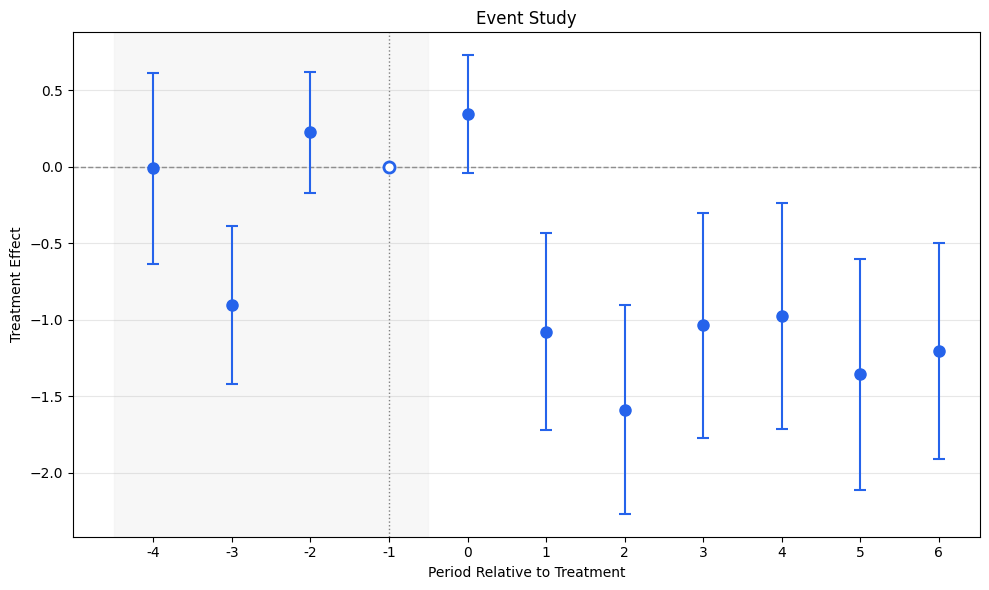

<Axes: title={'center': 'Event Study'}, xlabel='Period Relative to Treatment', ylabel='Treatment Effect'>

In [665]:
plot_event_study(results_semester, periods = [-4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6])

In [666]:
df_semester_agg.to_csv('../../../data/output/conflict_level/semester_sample_for_csdid.csv', index=False)